# Exploratory Data Analysis

Exploring the data of the financial and disaster datasets.

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd

from climatefinance import plots, utils

In [2]:
# Read data
analysis_df = utils.load_analysis_data()
# Fix datetime loading from csv file
analysis_df["month"] = pd.to_datetime(analysis_df["month"])

Loaded 73899 rows from data/analysis/finance_disaster_analysis.csv


In [3]:
# Count number of treated and controled groups
analysis_df["event_occur"].value_counts(dropna=False)

event_occur
0.0    72735
1.0     1164
Name: count, dtype: int64

Saved data/figures/eda/disaster_frequency.png


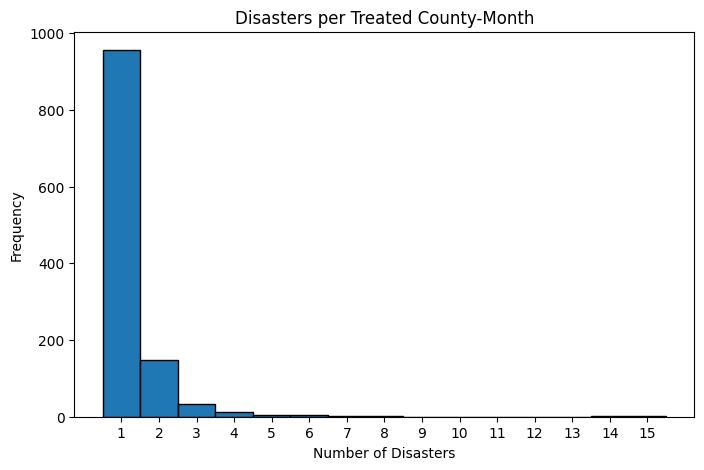

In [4]:
plots.plot_eda_disaster_frequency(analysis_df);

We seem to mostly have event markers correspond to single event, but we should check if multiple disasters is a cause of concern.

Saved data/figures/eda/top_disaster_types.png


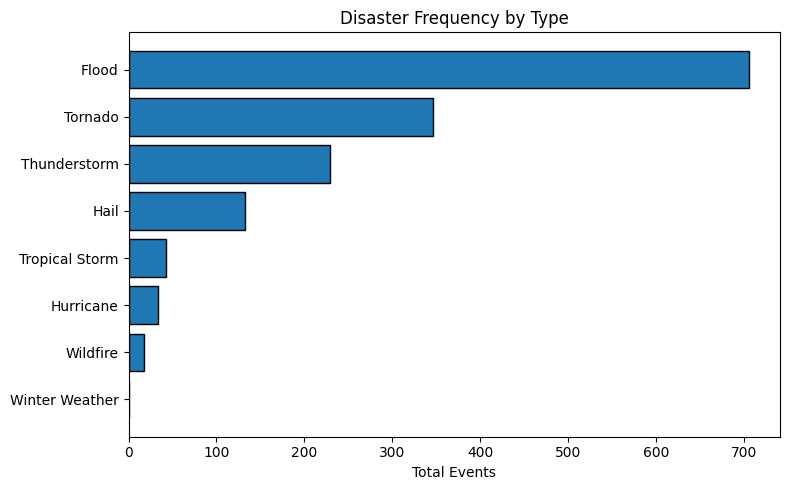

In [5]:
plots.plot_eda_top_disaster_types(analysis_df);

Saved data/figures/eda/delinquency_over_time.png


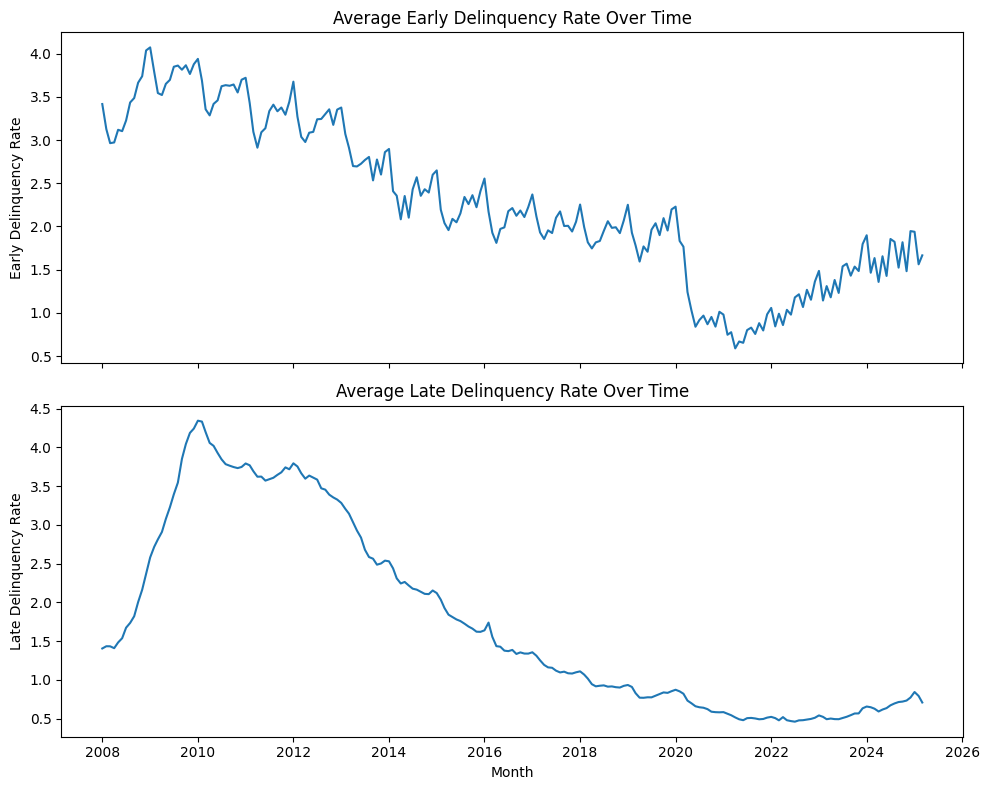

In [6]:
plots.plot_eda_delinquency_over_time(analysis_df);

Saved data/figures/eda/damage_distribution.png


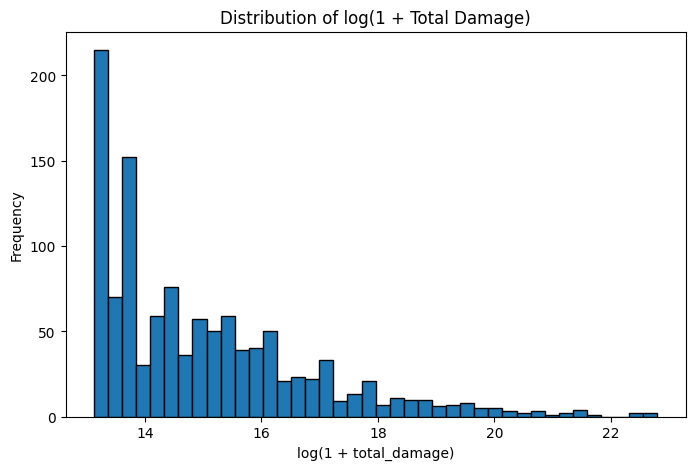

In [7]:
plots.plot_eda_damage_distribution(analysis_df);

             Early_Delinquency_Rate  Late_Delinquency_Rate
event_occur                                               
0.0                        2.276751               1.772074
1.0                        2.477320               1.921306
Saved data/figures/eda/delinquency_by_treatment.png


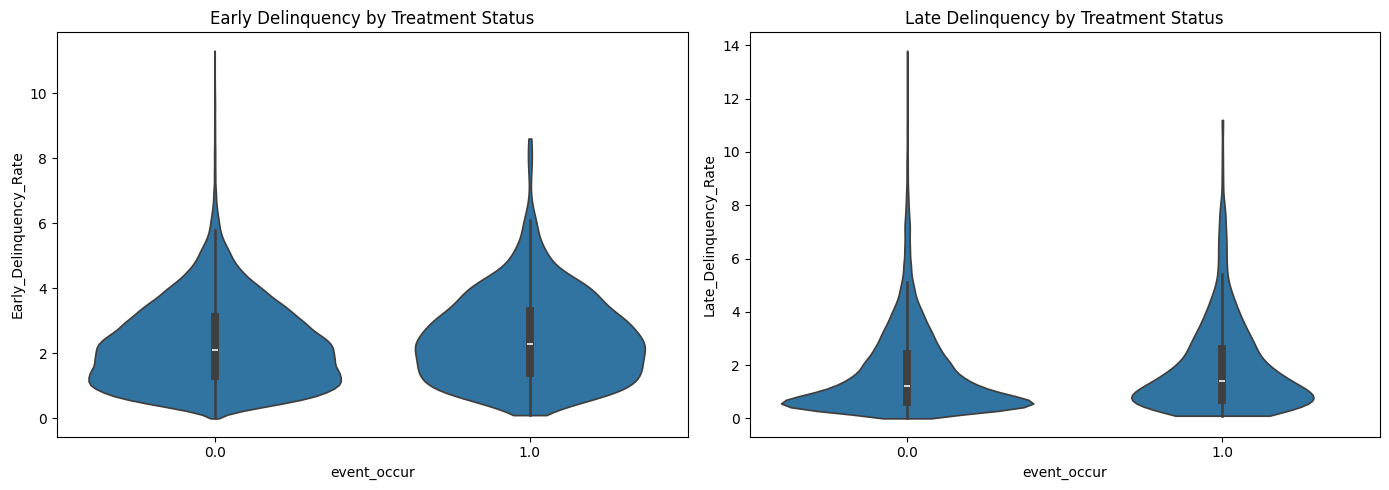

In [8]:
# Mean delinquency in treated vs untreated county-months
comparison = analysis_df.groupby("event_occur")[
    ["Early_Delinquency_Rate", "Late_Delinquency_Rate"]
].mean()
print(comparison)

plots.plot_eda_delinquency_by_treatment(analysis_df);

We seem to have a lot of outliers.

In [9]:
# How many counties are ever treated?
treated_counties = analysis_df.loc[analysis_df["event_occur"] == 1, "fips"].nunique()
print("Counties ever treated:", treated_counties)
print("Share of counties ever treated:", treated_counties / analysis_df["fips"].nunique())

Counties ever treated: 325
Share of counties ever treated: 0.9103641456582633


In [10]:
# Counties that experienced most events
county_treatment_counts = (
    analysis_df.groupby("fips")["event_occur"]
    .sum()
    .sort_values(ascending=False)
)

print(county_treatment_counts.describe())
print(county_treatment_counts.head(20))

count    357.000000
mean       3.260504
std        2.547731
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max       15.000000
Name: event_occur, dtype: float64
fips
48303    15.0
28121    14.0
47037    13.0
12127    13.0
4019     13.0
48453    12.0
22015    10.0
26081    10.0
13139    10.0
39153     9.0
47189     9.0
26163     9.0
37183     9.0
48245     9.0
47125     9.0
22055     9.0
4025      8.0
37119     8.0
12011     8.0
12115     8.0
Name: event_occur, dtype: float64


Saved data/figures/eda/treatment_rate.png


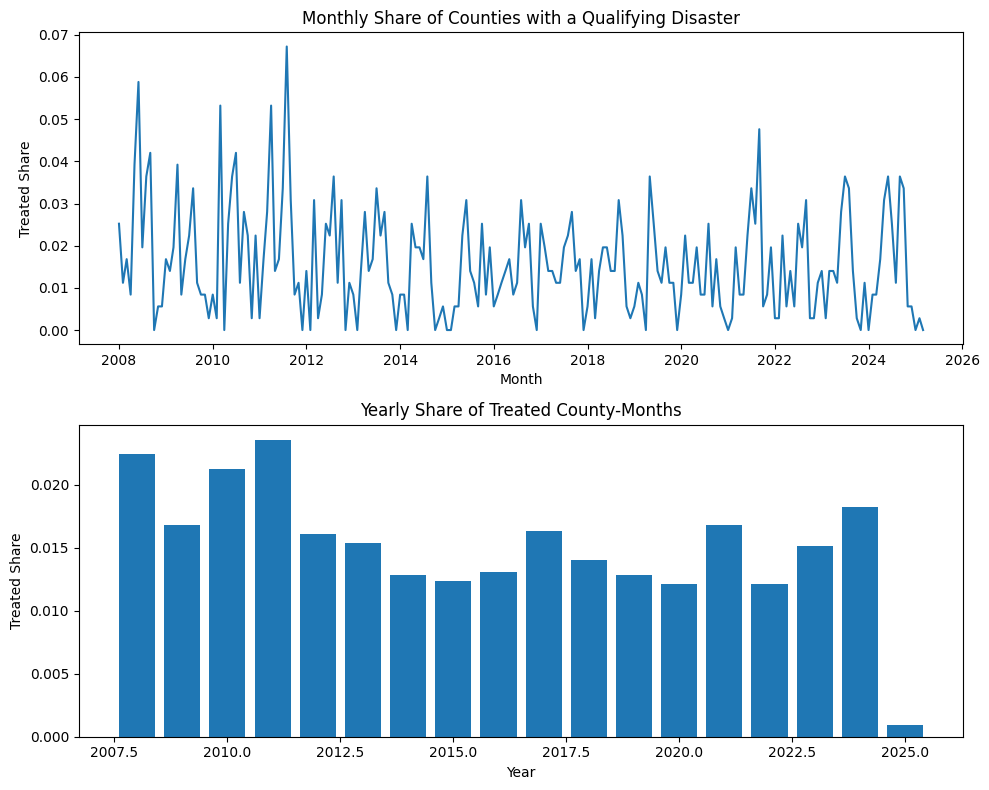

In [11]:
plots.plot_eda_treatment_rate(analysis_df);

Treatment is rare in time, but common across counties

- Only ~1.46% of county-months are treated
- About 89.6% of counties are treated at least once

This is an important design insight. Our identification will come mostly from:
 - within-county timing
 - not from a large pool of never-treated counties

This fits a fixed-effects framework

Saved data/figures/eda/event_study_raw.png


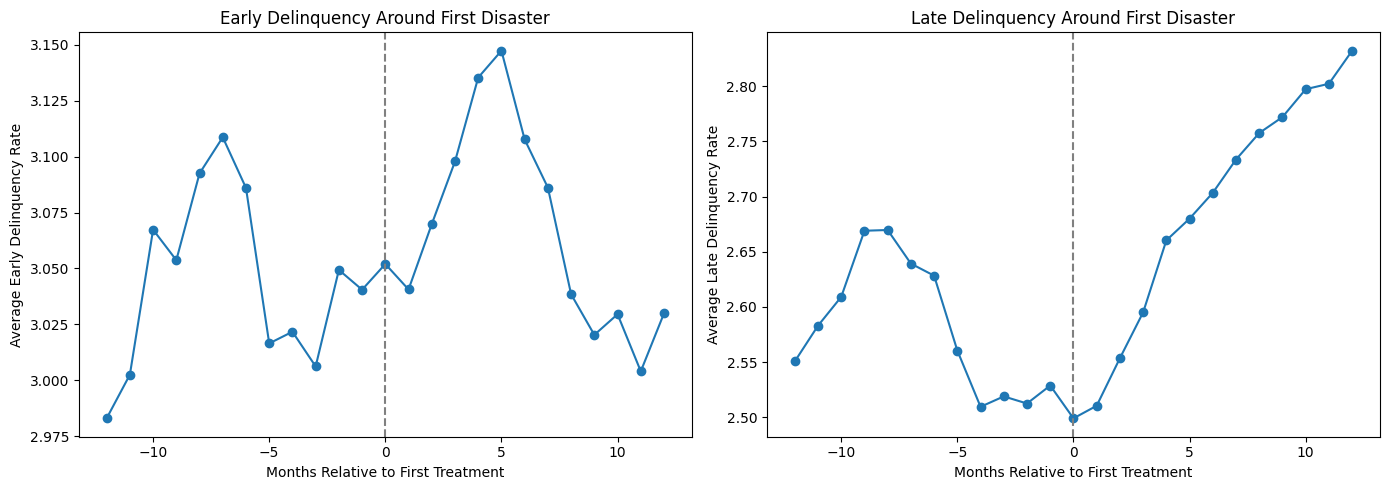

In [12]:
plots.plot_eda_event_study_raw(analysis_df);

Let's normalize by county baseline, so cross-county level differences do not dominate.

Saved data/figures/eda/event_study_demeaned.png


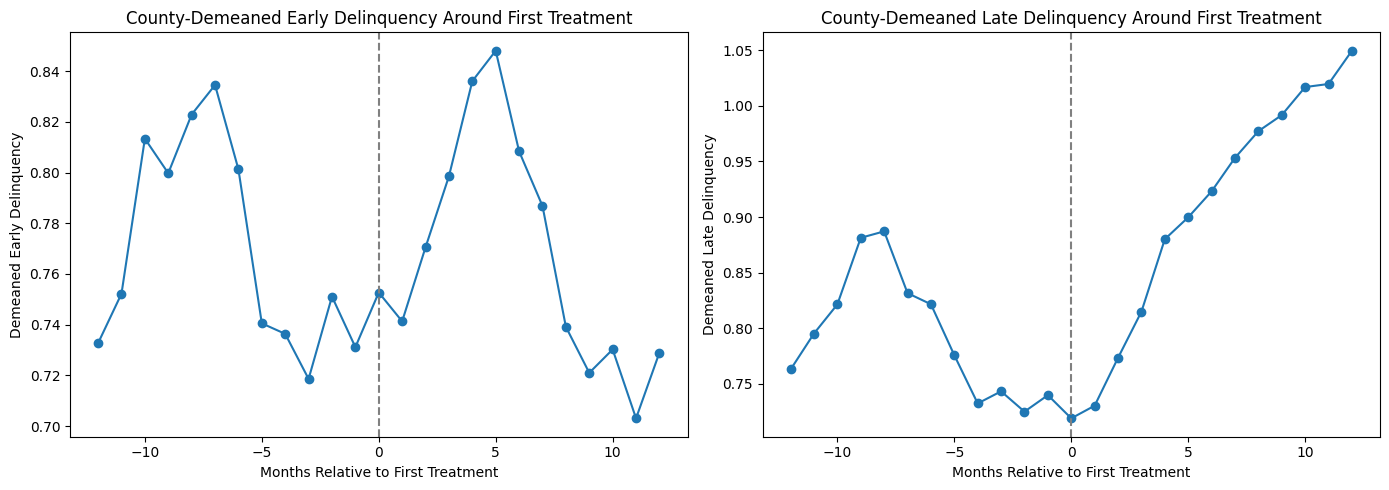

In [13]:
plots.plot_eda_event_study_demeaned(analysis_df);

This shows something very important:

- the treatment is rare over time,
- but fairly widespread across space.

That means identification does not come mainly from comparing treated counties to never-treated counties, but rather from within-county variation over time.
This strongly supports a fixed effects approach.